Todos os códigos presentes estão disponíveis em: https://github.com/Dhonrian/pos_ifnet/blob/main/25E4_2/clusterizacao.ipynb

### Para esta matéria será utilizado o mesmo ambiente de clusterização
<img src="resources/env.png">

### Dataset
O dataset escolhido foi um retirado do https://www.kaggle.com/datasets/umuttuygurr/city-lifestyle-segmentation-dataset/, que indica o estilo de vida de aproximadamente 300 cidades.

O objetivo é agrupar cidades semelhantes baseadas nas caracteristicas economicas, ambientais etc.

As features presentes são:

|Coluna|Tipo|Descrição|
|------|----|---------|
|city_name|string|Nome da cidade|
|country|string|Região em que a cidade é localizada|
|population_density|int|População por km²|
|avg_income|float|Média do salário em dólar|
|internet_penetration|float|Porcentagem de casas com acesso a internet|
|avg_rent|float|Média do aluguel de um apartamento|
|air_quality_index|int|Indíce de qualidade do ar (menor = melhor)|
|public_transport_score|float|Qualidade do transporte público|
|happiness_score|float|Valor entre 0-10 subjetivo de satisfação com a vida|
|green_space_ratio|float|Porcentagem da cidade coberta por parques/áreas verdes|

In [99]:
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster import hierarchy
import numpy as np

In [100]:
original_df = pd.read_csv('city_lifestyle_dataset.csv')

In [101]:
original_df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [102]:
original_df.describe()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


In [103]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


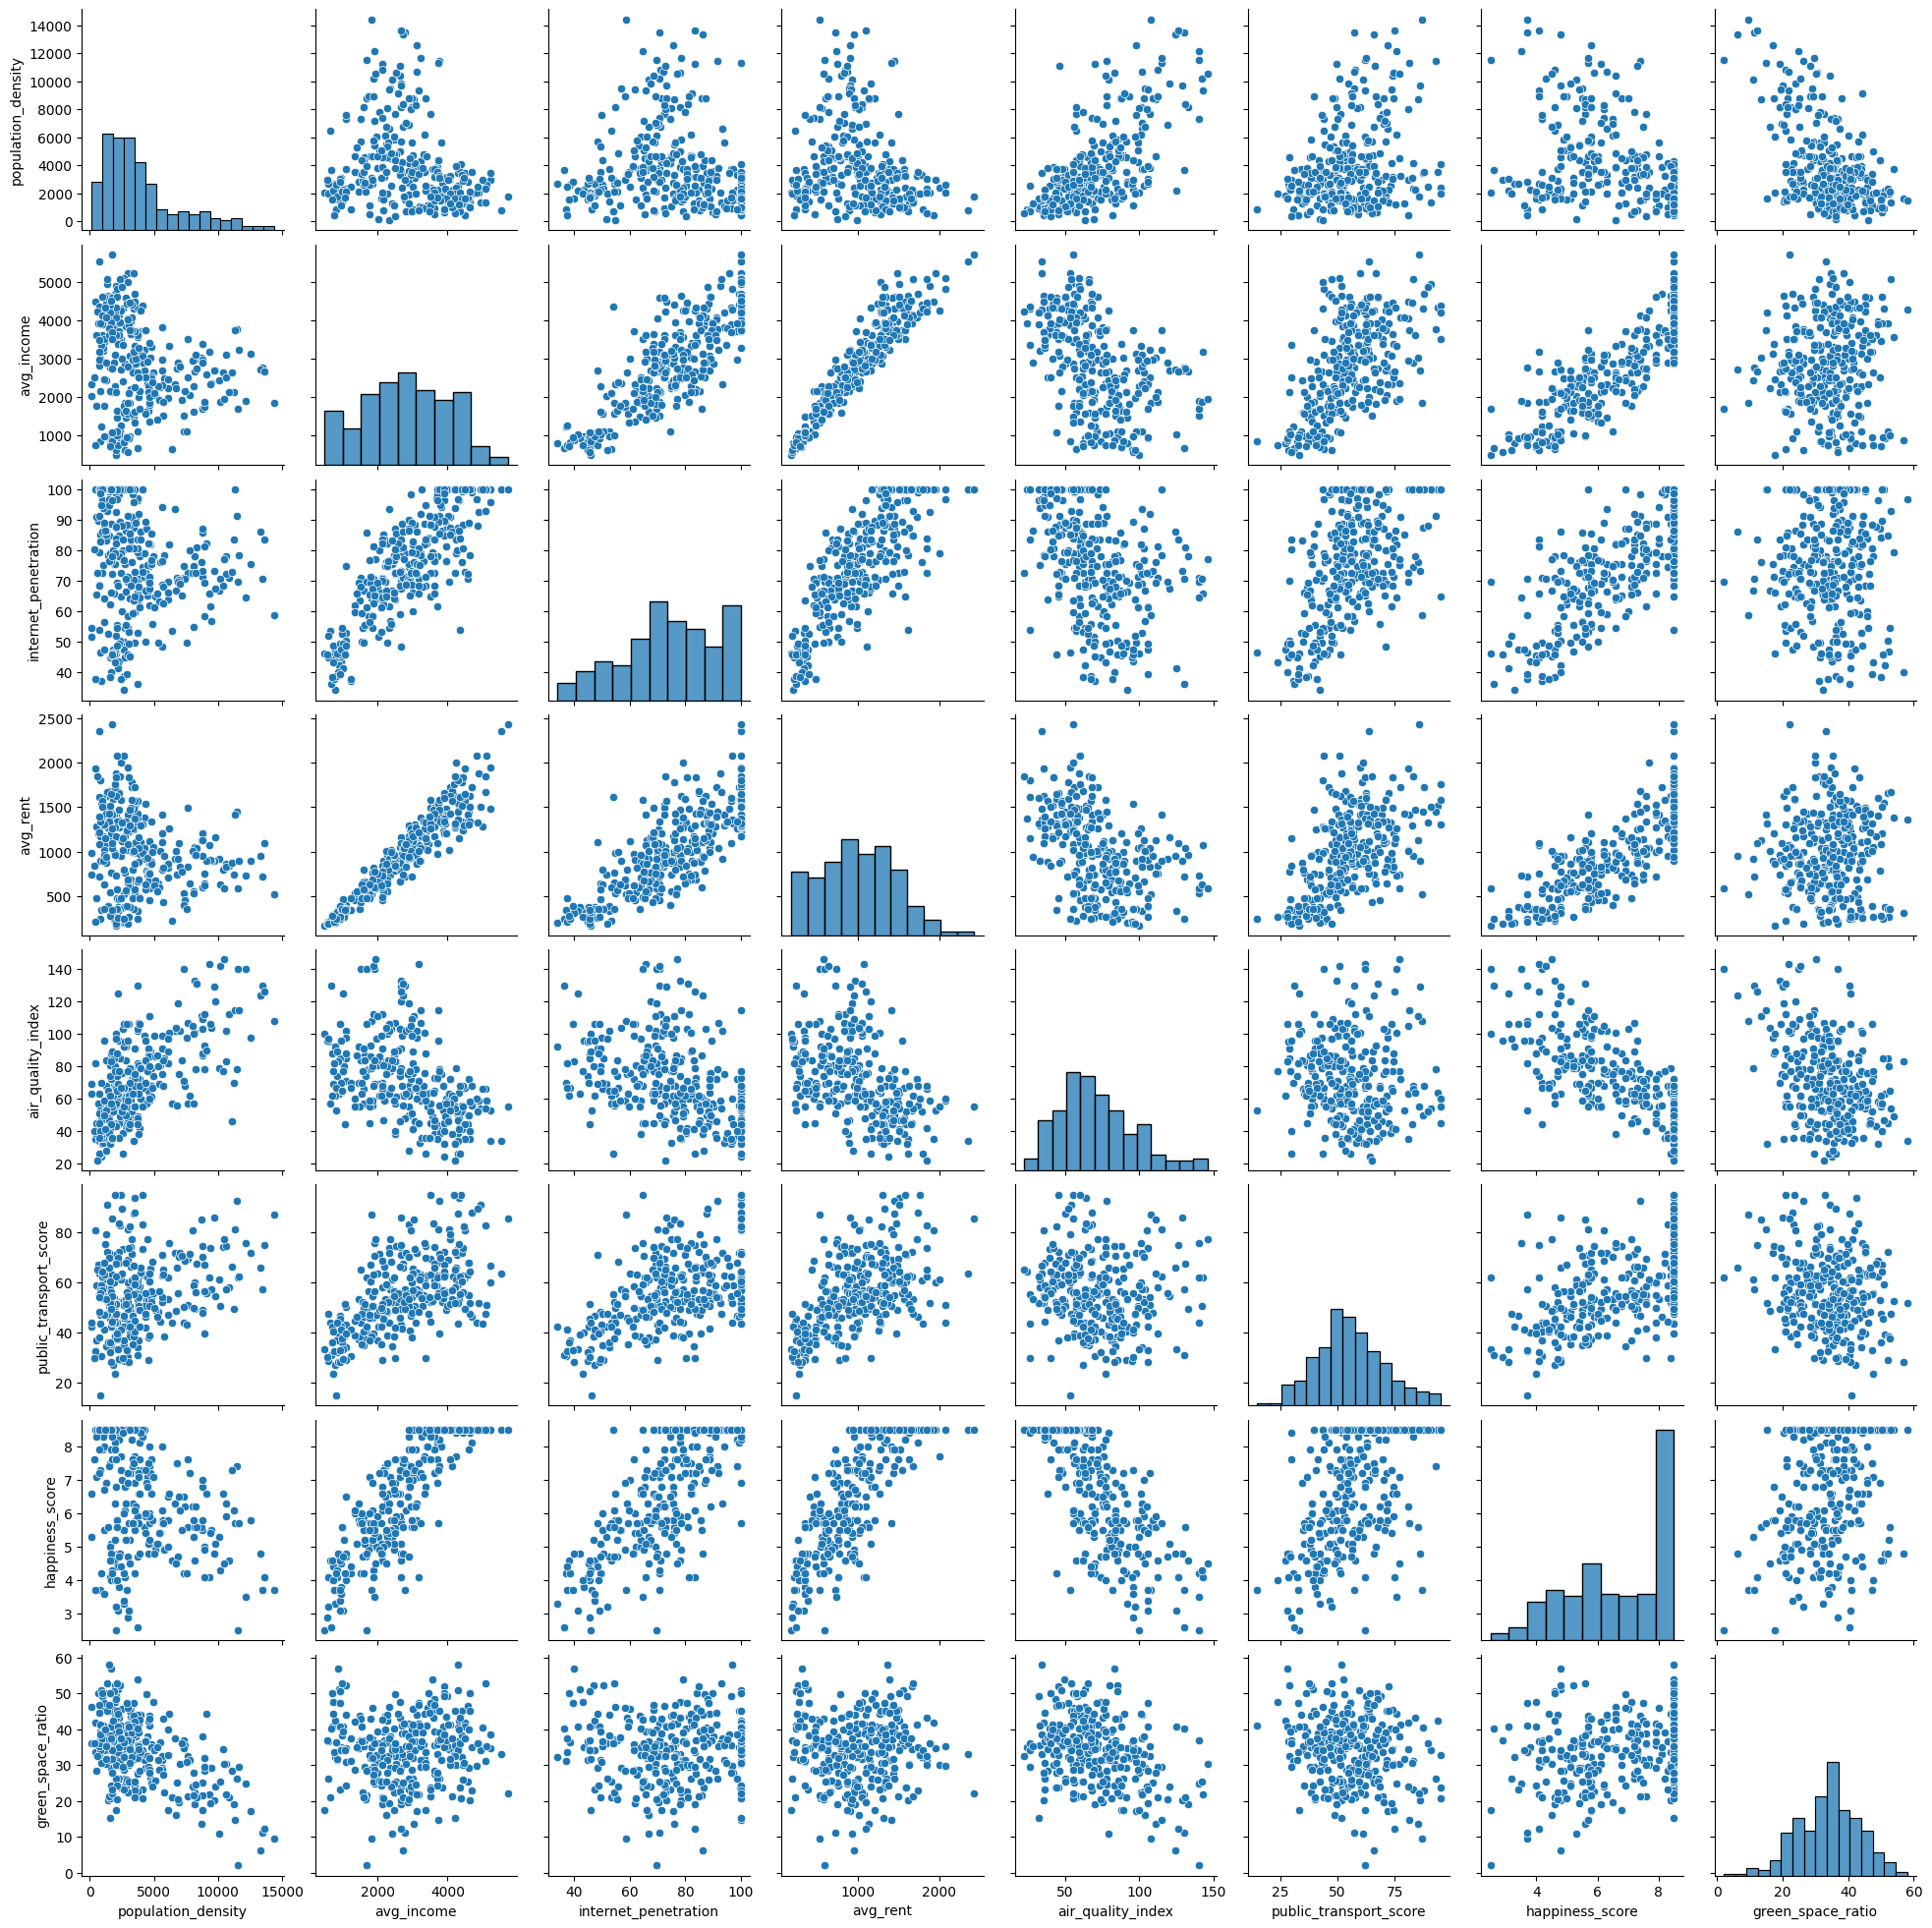

In [104]:
sns.pairplot(original_df)

## Pré processamento

In [105]:
categorical_cols = original_df.select_dtypes(include=['object','category']).columns.tolist()
numerical_cols   = original_df.select_dtypes(include=['int64','float64']).columns.tolist()

In [106]:
print("Categóricas:", categorical_cols)
print("Numéricas:", numerical_cols)

Categóricas: ['city_name', 'country']
Numéricas: ['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']


In [107]:
df = original_df.drop(columns=categorical_cols)

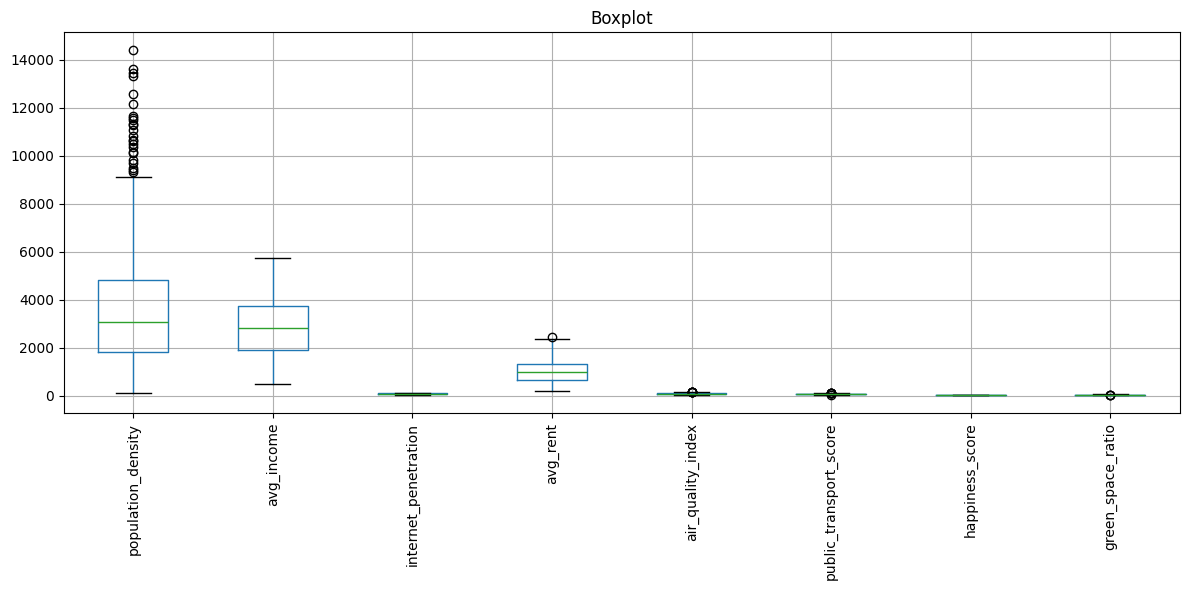

In [108]:
plt.figure(figsize=(12, 6))
df.boxplot()
plt.title("Boxplot")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

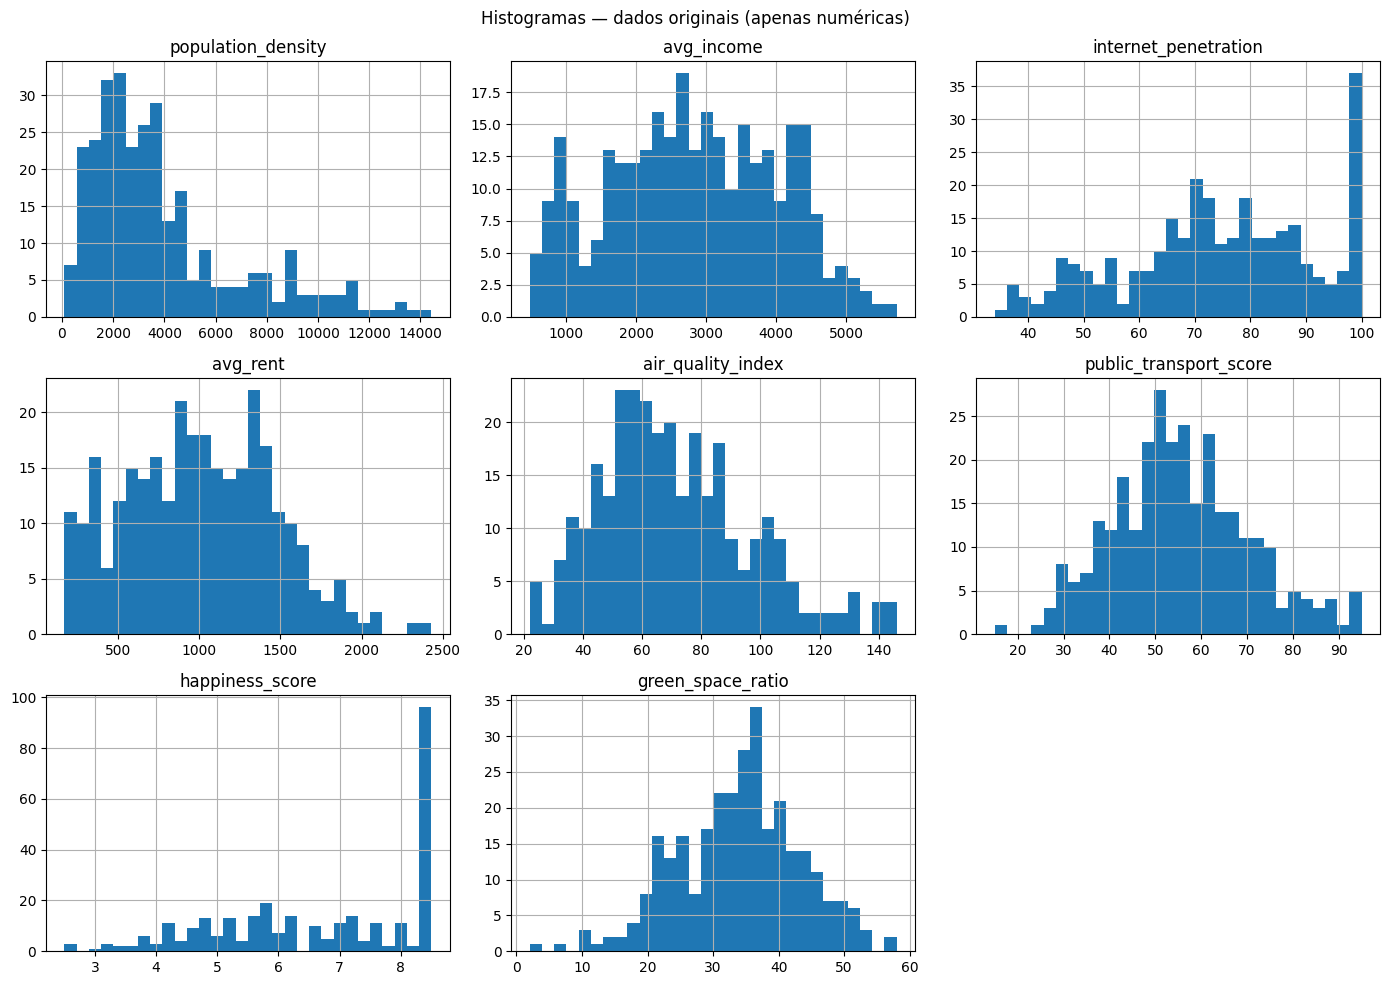

In [109]:
df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Histogramas — dados originais (apenas numéricas)")
plt.tight_layout()
plt.show()

Existe uma diferença de escala nos dados então iremos deixar todos na mesma faixa usando o StandardScaler

In [110]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled, columns=df.columns)

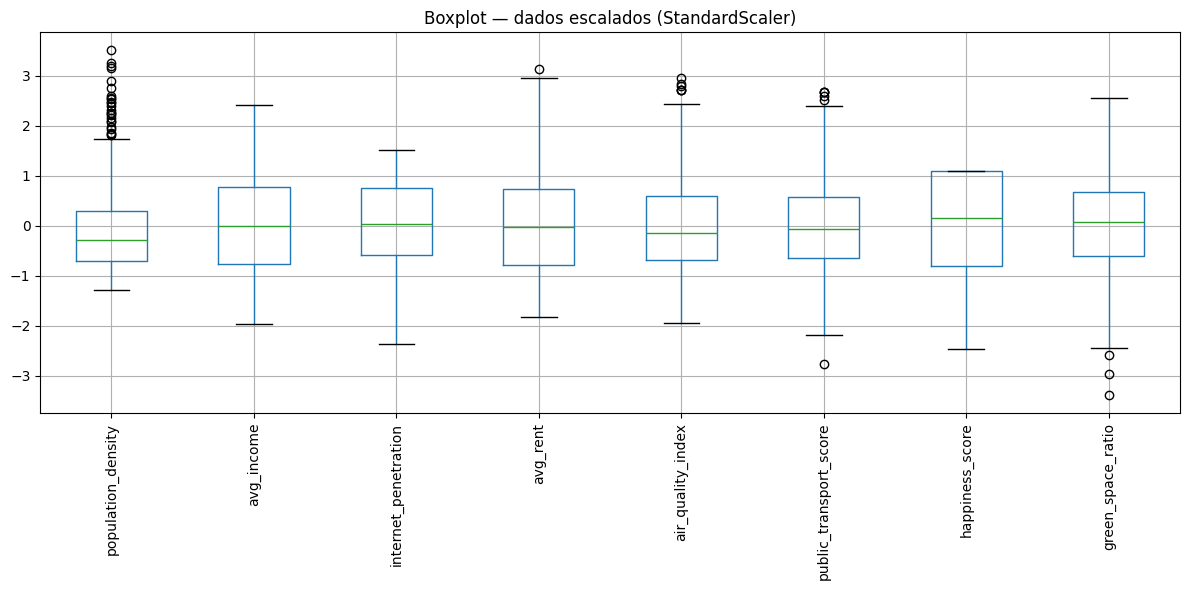

In [111]:
plt.figure(figsize=(12, 6))
scaled_df.boxplot()
plt.title("Boxplot — dados escalados (StandardScaler)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

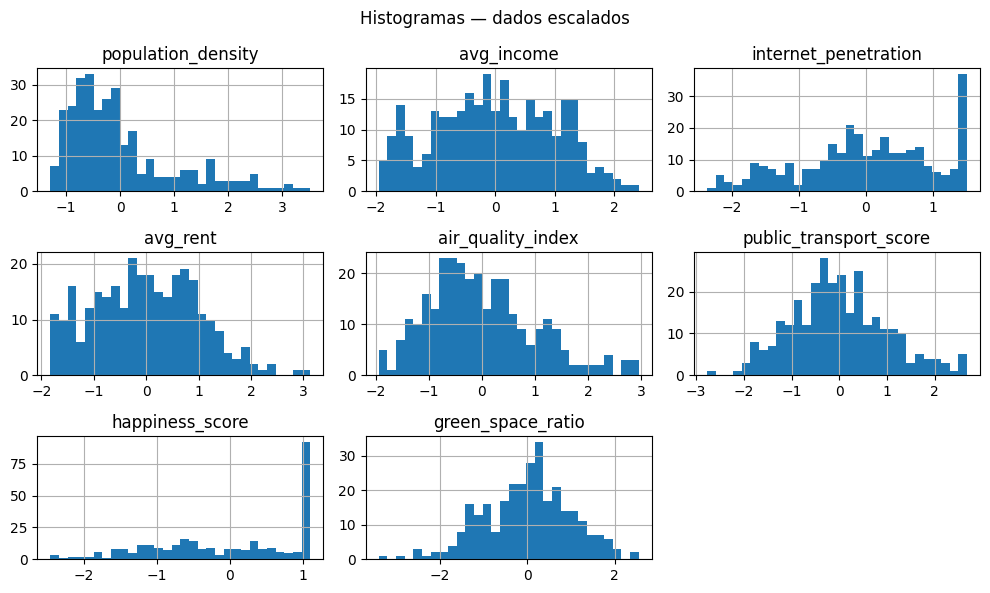

In [112]:
scaled_df.hist(figsize=(10, 6), bins=30)
plt.suptitle("Histogramas — dados escalados")
plt.tight_layout()
plt.show()

In [113]:
pca = PCA(n_components=2, random_state=10)
X_pca = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})

In [114]:
N_CLUSTERS = 3 #número padrão por enquanto
SEED = 10
X = scaled_df.values

In [ ]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED).fit(X)
pca_df["kmeans_cluster"] = kmeans.labels_

In [120]:
dbscan = DBSCAN().fit(X)
pca_df['db_cluster'] = dbscan.labels_

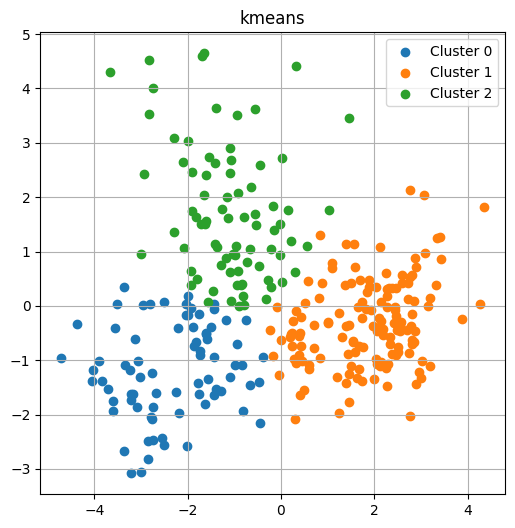

In [117]:
plt.figure(figsize=(6,6))
for c in range(N_CLUSTERS):
    cluster_points = pca_df[pca_df["kmeans_cluster"] == c]
    plt.scatter(cluster_points["PC1"], cluster_points["PC2"], label=f"Cluster {c}")

plt.title("kmeans")
plt.legend()
plt.grid(True)
plt.show()